# Task 3: Transformer manual para forecasting

## 1. Preparación de datos

In [8]:
import ssl
import urllib.error
import urllib.request
from pathlib import Path

import certifi
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
print(f'PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cpu


In [9]:
URL = (
    'https://raw.githubusercontent.com/zhouhaoyi/'
    'ETDataset/main/ETT-small/ETTh1.csv'
)
DATA_PATH = Path('ETTh1.csv')

if not DATA_PATH.exists():
    try:
        urllib.request.urlretrieve(URL, DATA_PATH)
    except urllib.error.URLError as error:
        if DATA_PATH.exists():
            DATA_PATH.unlink()
        ssl_context = ssl.create_default_context(cafile=certifi.where())
        with urllib.request.urlopen(URL, context=ssl_context) as response:
            DATA_PATH.write_bytes(response.read())
        print(f'La descarga estándar falló ({error.reason}); se usó certifi.')

data = np.genfromtxt(DATA_PATH, delimiter=',', skip_header=1)
OT = data[:, -1].astype(np.float32)
OT_tensor = torch.from_numpy(OT)
mu = OT_tensor.mean()
sigma = OT_tensor.std(correction=0)
OT_norm = (OT_tensor - mu) / sigma

T = OT_norm.numel()
train_end = int(0.60 * T)
val_end = int(0.80 * T)
OT_train = OT_norm[:train_end].clone()
OT_val = OT_norm[train_end:val_end].clone()
OT_test = OT_norm[val_end:].clone()

print(f'Train={OT_train.shape}, val={OT_val.shape}, test={OT_test.shape}')

Train=torch.Size([10452]), val=torch.Size([3484]), test=torch.Size([3484])


In [10]:
def make_windows(series: torch.Tensor, L: int, H: int):
    windows = series.unfold(0, L + H, 1)
    return windows[:, :L].contiguous(), windows[:, -1].contiguous()

L = 96
X_tr_24, y_tr_24 = make_windows(OT_train, L, 24)
X_vl_24, y_vl_24 = make_windows(OT_val, L, 24)
X_ts_24, y_ts_24 = make_windows(OT_test, L, 24)
X_tr_48, y_tr_48 = make_windows(OT_train, L, 48)
X_vl_48, y_vl_48 = make_windows(OT_val, L, 48)
X_ts_48, y_ts_48 = make_windows(OT_test, L, 48)

naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
print(f'Naive MAE H=24: {naive_mae:.4f}')

Naive MAE H=24: 0.1996


# Task 3.1: Positional encoding

## 1. `make_pe`

$$\mathrm{PE}(t, 2i) = \sin\left(\frac{t}{10000^{2i/d_{model}}}\right), \qquad \mathrm{PE}(t, 2i+1) = \cos\left(\frac{t}{10000^{2i/d_{model}}}\right)$$

In [11]:
def make_pe(max_len, d_model):
    t = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
    two_i = torch.arange(0, d_model, 2, dtype=torch.float32)
    angles = t / torch.pow(10000.0, two_i / d_model)

    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(angles)
    pe[:, 1::2] = torch.cos(angles[:, :d_model // 2])
    return pe

In [12]:
_pe = make_pe(96, 32)

assert _pe.shape == (96, 32), f'Forma incorrecta: {_pe.shape}'
assert not _pe.requires_grad, 'El positional encoding no debe ser aprendible'
assert torch.allclose(_pe[0, 0::2], torch.zeros(16)) and torch.allclose(_pe[0, 1::2], torch.ones(16))
assert torch.isclose(_pe[5, 2], torch.sin(torch.tensor(5 / 10000 ** (2 / 32))))
assert torch.isclose(_pe[5, 3], torch.cos(torch.tensor(5 / 10000 ** (2 / 32))))
assert make_pe(10, 7).shape == (10, 7)

print(f'PE shape: {tuple(_pe.shape)}, requires_grad={_pe.requires_grad}')

PE shape: (96, 32), requires_grad=False


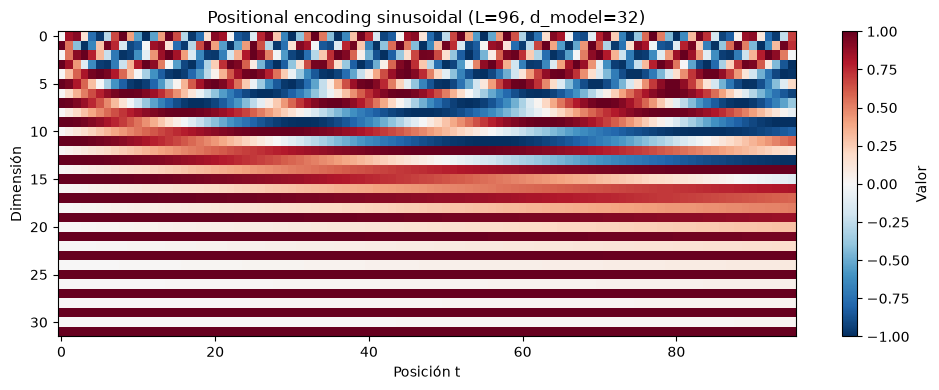

In [13]:
plt.figure(figsize=(10, 4))
plt.imshow(_pe.T.numpy(), aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Valor')
plt.xlabel('Posición t')
plt.ylabel('Dimensión')
plt.title('Positional encoding sinusoidal (L=96, d_model=32)')
plt.tight_layout()
plt.show()

## 2. Proyección de la entrada a $\mathbb{R}^{d_{model}}$

Cada escalar $x_t$ se proyecta con `nn.Linear(1, d_model)` y luego se suma el positional encoding. Esta misma operación es el primer paso de `TransformerForecaster.forward` (Task 3.2).

In [14]:
_input_proj = nn.Linear(1, 32)
_x = X_tr_24[:4]
_embedded = _input_proj(_x.unsqueeze(-1)) + _pe[:L]

assert _embedded.shape == (4, L, 32), f'Forma incorrecta: {_embedded.shape}'
print(f'x: {tuple(_x.shape)} -> input_proj + PE: {tuple(_embedded.shape)}')

x: (4, 96) -> input_proj + PE: (4, 96, 32)


# Task 3.2: `TransformerForecaster`

Encoder de una capa implementado con tensores: multi-head self-attention, Add & Norm, feed-forward y Add & Norm. La predicción se lee de la posición 0, que actúa como token CLS.

In [15]:
class TransformerForecaster(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, L):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.L = L
        assert self.d_k * n_heads == d_model, 'd_model debe ser divisible por n_heads'

        self.input_proj = nn.Linear(1, d_model)
        self.register_buffer('PE', make_pe(L, d_model))

        self.WQ = nn.Parameter(torch.empty(d_model, d_model))
        self.WK = nn.Parameter(torch.empty(d_model, d_model))
        self.WV = nn.Parameter(torch.empty(d_model, d_model))
        self.WO = nn.Parameter(torch.empty(d_model, d_model))

        self.W1 = nn.Parameter(torch.empty(d_model, d_ff))
        self.b1 = nn.Parameter(torch.zeros(d_ff))
        self.W2 = nn.Parameter(torch.empty(d_ff, d_model))
        self.b2 = nn.Parameter(torch.zeros(d_model))

        self.gamma1 = nn.Parameter(torch.ones(d_model))
        self.beta1 = nn.Parameter(torch.zeros(d_model))
        self.gamma2 = nn.Parameter(torch.ones(d_model))
        self.beta2 = nn.Parameter(torch.zeros(d_model))

        self.W_out = nn.Linear(d_model, 1)

        for W in (self.WQ, self.WK, self.WV, self.WO, self.W1, self.W2):
            nn.init.xavier_uniform_(W)

    def layer_norm(self, x, gamma, beta, eps=1e-5):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return gamma * (x - mean) / torch.sqrt(var + eps) + beta

    def multi_head_attention(self, x):
        B, L, _ = x.shape

        Q = x @ self.WQ
        K = x @ self.WK
        V = x @ self.WV

        Q = Q.reshape(B, L, self.n_heads, self.d_k).transpose(1, 2)
        K = K.reshape(B, L, self.n_heads, self.d_k).transpose(1, 2)
        V = V.reshape(B, L, self.n_heads, self.d_k).transpose(1, 2)

        scores = Q @ K.transpose(-2, -1) / self.d_k ** 0.5
        attn_w = torch.softmax(scores, dim=-1)
        out = attn_w @ V

        out = out.transpose(1, 2).reshape(B, L, self.d_model)
        return out @ self.WO, attn_w

    def feed_forward(self, x):
        return torch.relu(x @ self.W1 + self.b1) @ self.W2 + self.b2

    def forward(self, x, return_attn=False):
        L = x.shape[1]
        x = self.input_proj(x.unsqueeze(-1)) + self.PE[:L]

        att_out, attn_w = self.multi_head_attention(x)
        x = self.layer_norm(x + att_out, self.gamma1, self.beta1)

        ff_out = self.feed_forward(x)
        x = self.layer_norm(x + ff_out, self.gamma2, self.beta2)

        pred = self.W_out(x[:, 0, :]).squeeze(-1)
        if return_attn:
            return pred, attn_w
        return pred

## Verificación de componentes

In [16]:
torch.manual_seed(0)
_trf = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
_x = torch.randn(4, 96)

_pred, _attn = _trf(_x, return_attn=True)
assert _pred.shape == (4,), f'pred shape incorrecto: {_pred.shape}'
assert _attn.shape == (4, 2, 96, 96), f'attn shape incorrecto: {_attn.shape}'
assert torch.allclose(_attn.sum(-1), torch.ones(4, 2, 96), atol=1e-5)
assert _trf(_x).shape == (4,)

_h = torch.randn(4, 96, 32)
_ln_ref = F.layer_norm(_h, (32,), _trf.gamma1, _trf.beta1, eps=1e-5)
assert torch.allclose(_trf.layer_norm(_h, _trf.gamma1, _trf.beta1), _ln_ref, atol=1e-5), \
    'layer_norm no coincide con la referencia'

assert 'PE' in dict(_trf.named_buffers()) and 'PE' not in dict(_trf.named_parameters()), \
    'El PE debe ser un buffer no aprendible'

_n_params = sum(p.numel() for p in _trf.parameters())
print(f'pred: {tuple(_pred.shape)}, attn_w: {tuple(_attn.shape)}')
print(f'Parámetros entrenables: {_n_params}')

pred: (4,), attn_w: (4, 2, 96, 96)
Parámetros entrenables: 8513


# Task 3.3: Entrenamiento, evaluación y atención

## 1. Entrenamiento para $H=24$ y $H=48$

Se usan las mismas condiciones que el LSTM de la Task 2: 20 épocas, Adam (lr=5e-3), batch_size=64, pérdida MAE, clipping de gradiente en 5.0, se conserva el mejor estado según MAE de validación y las mismas semillas (42 para H=24, 90 para H=48).

In [17]:
def forecasting_loss(pred, target):
    return F.l1_loss(pred, target)


def predict_batched(model, X, batch_size=256):
    model.eval()
    predictions = []
    with torch.no_grad():
        for start in range(0, X.shape[0], batch_size):
            predictions.append(model(X[start:start + batch_size]))
    return torch.cat(predictions)


def train_transformer(X, y, X_val, y_val, epochs=20, batch_size=64, lr=5e-3, seed=42):
    torch.manual_seed(seed)
    model = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    N = X.shape[0]
    best_val_mae = float('inf')
    best_state = None

    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(N)
        total_loss = 0.0

        for start in range(0, N, batch_size):
            indices = permutation[start:start + batch_size]
            X_batch = X[indices]
            y_batch = y[indices]

            optimizer.zero_grad(set_to_none=True)
            pred = model(X_batch)
            loss = forecasting_loss(pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            total_loss += loss.item() * X_batch.shape[0]

        epoch_loss = total_loss / N
        losses.append(epoch_loss)
        val_pred = predict_batched(model, X_val)
        val_mae = torch.abs(y_val - val_pred).mean().item()
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = {name: value.detach().clone() for name, value in model.state_dict().items()}
        print(f'Época {epoch + 1:02d}/{epochs}: MAE train={epoch_loss:.6f}, MAE val={val_mae:.6f}')

    model.load_state_dict(best_state)
    return model, losses

In [18]:
print('Entrenamiento H=24')
model_trf_24, loss_trf_24 = train_transformer(
    X_tr_24, y_tr_24, X_vl_24, y_vl_24,
    epochs=20, batch_size=64, lr=5e-3, seed=42
)

Entrenamiento H=24
Época 01/20: MAE train=0.317100, MAE val=0.476105
Época 02/20: MAE train=0.277637, MAE val=0.303812
Época 03/20: MAE train=0.281814, MAE val=0.283500
Época 04/20: MAE train=0.276807, MAE val=0.360806
Época 05/20: MAE train=0.275655, MAE val=0.348834
Época 06/20: MAE train=0.272779, MAE val=0.228796
Época 07/20: MAE train=0.274232, MAE val=0.265817
Época 08/20: MAE train=0.271730, MAE val=0.255335
Época 09/20: MAE train=0.272110, MAE val=0.284951
Época 10/20: MAE train=0.272308, MAE val=0.219616
Época 11/20: MAE train=0.271667, MAE val=0.299038
Época 12/20: MAE train=0.272947, MAE val=0.236005
Época 13/20: MAE train=0.268924, MAE val=0.231199
Época 14/20: MAE train=0.269339, MAE val=0.264832
Época 15/20: MAE train=0.268717, MAE val=0.220320
Época 16/20: MAE train=0.270189, MAE val=0.282222
Época 17/20: MAE train=0.268155, MAE val=0.278011
Época 18/20: MAE train=0.268862, MAE val=0.238150
Época 19/20: MAE train=0.268286, MAE val=0.269392
Época 20/20: MAE train=0.268103

In [19]:
print('Entrenamiento H=48')
model_trf_48, loss_trf_48 = train_transformer(
    X_tr_48, y_tr_48, X_vl_48, y_vl_48,
    epochs=20, batch_size=64, lr=5e-3, seed=90
)

Entrenamiento H=48
Época 01/20: MAE train=0.370650, MAE val=0.319022
Época 02/20: MAE train=0.338041, MAE val=0.306870
Época 03/20: MAE train=0.333287, MAE val=0.271402
Época 04/20: MAE train=0.335571, MAE val=0.296982
Época 05/20: MAE train=0.339908, MAE val=0.328383
Época 06/20: MAE train=0.329345, MAE val=0.415816
Época 07/20: MAE train=0.328680, MAE val=0.422864
Época 08/20: MAE train=0.332720, MAE val=0.321295
Época 09/20: MAE train=0.330840, MAE val=0.346755
Época 10/20: MAE train=0.328254, MAE val=0.390000
Época 11/20: MAE train=0.327983, MAE val=0.413149
Época 12/20: MAE train=0.326908, MAE val=0.375174
Época 13/20: MAE train=0.329337, MAE val=0.392665
Época 14/20: MAE train=0.329884, MAE val=0.357571
Época 15/20: MAE train=0.326924, MAE val=0.353593
Época 16/20: MAE train=0.326640, MAE val=0.371137
Época 17/20: MAE train=0.327678, MAE val=0.429719
Época 18/20: MAE train=0.326741, MAE val=0.382904
Época 19/20: MAE train=0.326876, MAE val=0.435530
Época 20/20: MAE train=0.328621

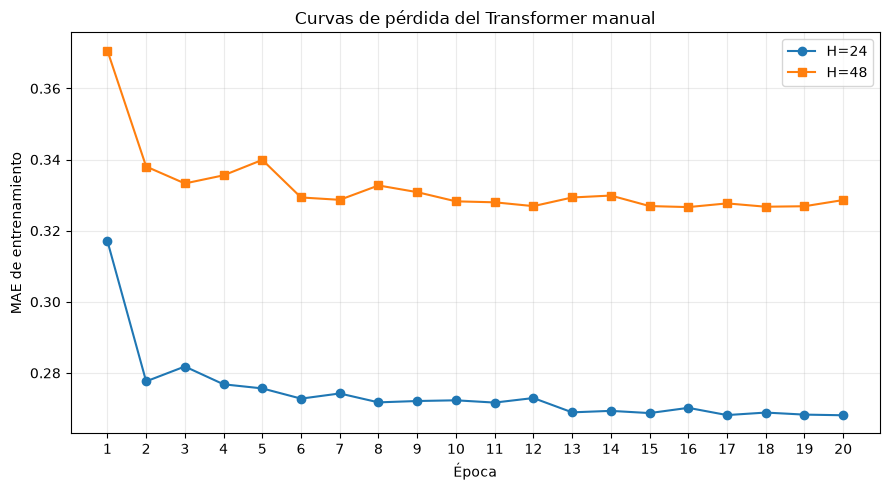

In [20]:
epochs = torch.arange(1, 21)
plt.figure(figsize=(9, 5))
plt.plot(epochs.numpy(), loss_trf_24, marker='o', label='H=24')
plt.plot(epochs.numpy(), loss_trf_48, marker='s', label='H=48')
plt.xlabel('Época')
plt.ylabel('MAE de entrenamiento')
plt.title('Curvas de pérdida del Transformer manual')
plt.xticks(epochs.numpy())
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 2. Métricas de validación

In [21]:
def regression_metrics(y, pred, X):
    mae = torch.abs(y - pred).mean().item()
    rmse = torch.sqrt(torch.mean((y - pred).square())).item()
    naive = torch.abs(y - X[:, -1]).mean().item()
    return {'MAE': mae, 'RMSE': rmse, 'MAE_naive': naive, 'ratio': mae / naive}

pred_vl_24 = predict_batched(model_trf_24, X_vl_24)
pred_vl_48 = predict_batched(model_trf_48, X_vl_48)
metrics_trf_24 = regression_metrics(y_vl_24, pred_vl_24, X_vl_24)
metrics_trf_48 = regression_metrics(y_vl_48, pred_vl_48, X_vl_48)

for horizon, metrics in ((24, metrics_trf_24), (48, metrics_trf_48)):
    print(
        f'H={horizon}: MAE={metrics["MAE"]:.4f}, RMSE={metrics["RMSE"]:.4f}, '
        f'MAE naive={metrics["MAE_naive"]:.4f}, ratio={metrics["ratio"]:.3f}'
    )

H=24: MAE=0.2196, RMSE=0.2856, MAE naive=0.1996, ratio=1.100
H=48: MAE=0.2714, RMSE=0.3406, MAE naive=0.2604, ratio=1.042


In [22]:
# Resultados del LSTM tomados de task_2_lstm.ipynb (misma validación y condiciones)
metrics_lstm = {
    24: {'MAE': 0.2038, 'RMSE': 0.2757, 'ratio': 1.021},
    48: {'MAE': 0.2690, 'RMSE': 0.3497, 'ratio': 1.033},
}
metrics_trf = {24: metrics_trf_24, 48: metrics_trf_48}

print(f'{"Modelo":<12}{"H":>4}{"MAE":>10}{"RMSE":>10}{"ratio":>10}')
for horizon in (24, 48):
    for name, metrics in (('LSTM', metrics_lstm[horizon]), ('Transformer', metrics_trf[horizon])):
        print(
            f'{name:<12}{horizon:>4}{metrics["MAE"]:>10.4f}'
            f'{metrics["RMSE"]:>10.4f}{metrics["ratio"]:>10.3f}'
        )

Modelo         H       MAE      RMSE     ratio
LSTM          24    0.2038    0.2757     1.021
Transformer   24    0.2196    0.2856     1.100
LSTM          48    0.2690    0.3497     1.033
Transformer   48    0.2714    0.3406     1.042


## 3. Mapas de atención

Se extraen los pesos de atención para 5 ejemplos de validación repartidos a lo largo del split y se promedian sobre los ejemplos y las 2 cabezas, obteniendo una matriz de forma $(L, L)$.

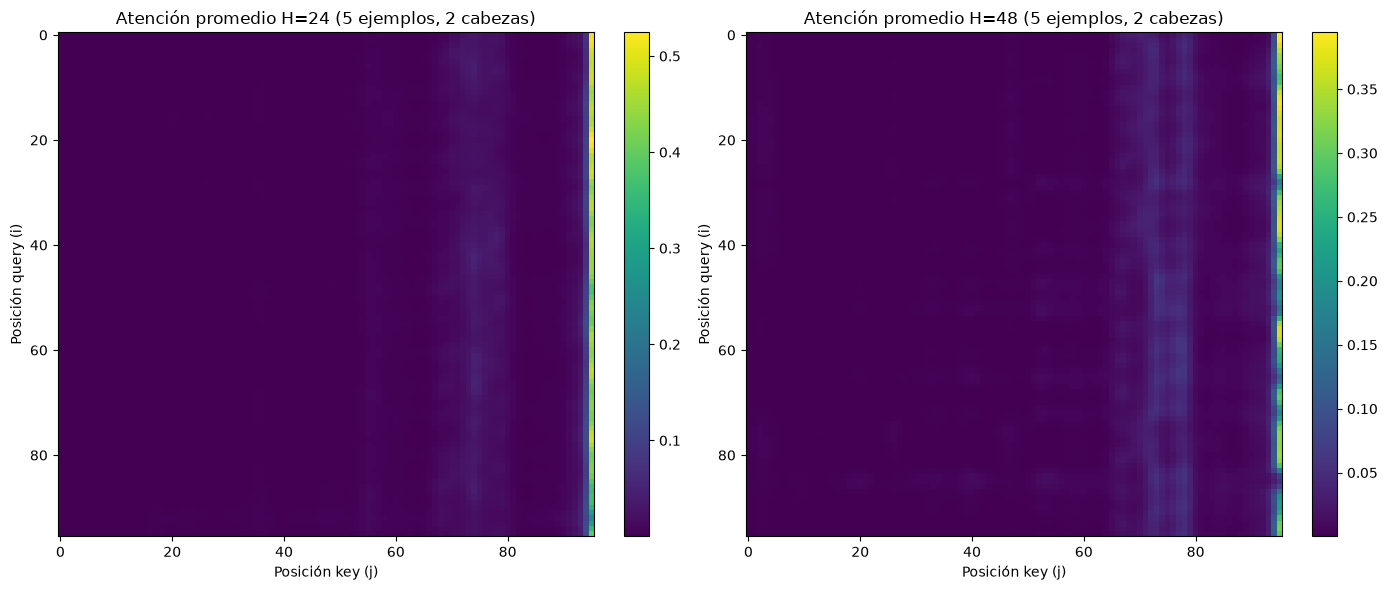

Ejemplos de validación usados H=24: [0, 841, 1682, 2523, 3364]
Ejemplos de validación usados H=48: [0, 835, 1670, 2505, 3340]


In [24]:
def attention_indices(X, n_examples=5):
    return torch.linspace(0, X.shape[0] - 1, n_examples).long()


def mean_attention(model, X):
    model.eval()
    with torch.no_grad():
        _, attn_w = model(X, return_attn=True)
    return attn_w.mean(dim=(0, 1))

attn_idx_24 = attention_indices(X_vl_24)
attn_idx_48 = attention_indices(X_vl_48)
attn_mean_24 = mean_attention(model_trf_24, X_vl_24[attn_idx_24])
attn_mean_48 = mean_attention(model_trf_48, X_vl_48[attn_idx_48])
assert attn_mean_24.shape == (L, L) and attn_mean_48.shape == (L, L)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, attn_mean, horizon in zip(axes, (attn_mean_24, attn_mean_48), (24, 48)):
    im = ax.imshow(attn_mean.numpy(), cmap='viridis', aspect='auto')
    ax.set_xlabel('Posición key (j)')
    ax.set_ylabel('Posición query (i)')
    ax.set_title(f'Atención promedio H={horizon} (5 ejemplos, 2 cabezas)')
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

print(f'Ejemplos de validación usados H=24: {attn_idx_24.tolist()}')
print(f'Ejemplos de validación usados H=48: {attn_idx_48.tolist()}')

## 4. Posiciones más atendidas desde la posición 0 (CLS)

La posición $j$ de la ventana corresponde al lag $L - j$: la posición 95 es el lag 1 (valor más reciente) y la posición 0 es el lag 96 (valor más antiguo).

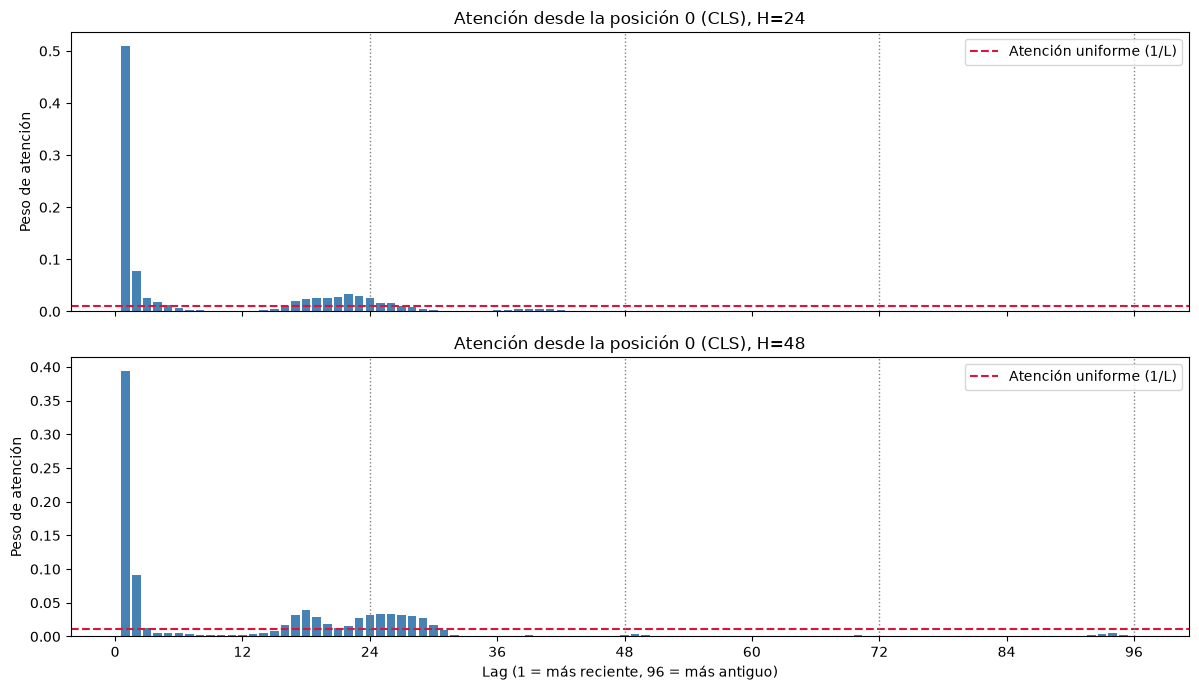


H=24: top 10 posiciones más atendidas desde CLS
  posición 95 -> lag  1: peso=0.5103
  posición 94 -> lag  2: peso=0.0767
  posición 74 -> lag 22: peso=0.0333
  posición 73 -> lag 23: peso=0.0291
  posición 75 -> lag 21: peso=0.0273
  posición 76 -> lag 20: peso=0.0257
  posición 77 -> lag 19: peso=0.0257
  posición 72 -> lag 24: peso=0.0255
  posición 93 -> lag  3: peso=0.0254
  posición 78 -> lag 18: peso=0.0247
  Masa de atención en los lags 1-24: 0.890 (uniforme: 0.250)

H=48: top 10 posiciones más atendidas desde CLS
  posición 95 -> lag  1: peso=0.3944
  posición 94 -> lag  2: peso=0.0912
  posición 78 -> lag 18: peso=0.0398
  posición 70 -> lag 26: peso=0.0340
  posición 71 -> lag 25: peso=0.0332
  posición 72 -> lag 24: peso=0.0321
  posición 69 -> lag 27: peso=0.0315
  posición 79 -> lag 17: peso=0.0313
  posición 68 -> lag 28: peso=0.0311
  posición 77 -> lag 19: peso=0.0290
  Masa de atención en los lags 1-24: 0.767 (uniforme: 0.250)


In [25]:
positions = torch.arange(L)
lags = L - positions

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, attn_mean, horizon in zip(axes, (attn_mean_24, attn_mean_48), (24, 48)):
    ax.bar(lags.numpy(), attn_mean[0].numpy(), color='steelblue')
    ax.axhline(1 / L, color='crimson', linestyle='--', label='Atención uniforme (1/L)')
    for daily_lag in (24, 48, 72, 96):
        ax.axvline(daily_lag, color='gray', linestyle=':', linewidth=1)
    ax.set_ylabel('Peso de atención')
    ax.set_title(f'Atención desde la posición 0 (CLS), H={horizon}')
    ax.legend()
axes[-1].set_xlabel('Lag (1 = más reciente, 96 = más antiguo)')
axes[-1].set_xticks(range(0, L + 1, 12))
plt.tight_layout()
plt.show()

for attn_mean, horizon in ((attn_mean_24, 24), (attn_mean_48, 48)):
    cls_attn = attn_mean[0]
    top = torch.topk(cls_attn, k=10)
    print(f'\nH={horizon}: top 10 posiciones más atendidas desde CLS')
    for weight, position in zip(top.values, top.indices):
        print(f'  posición {position.item():2d} -> lag {L - position.item():2d}: peso={weight.item():.4f}')
    recent_mass = cls_attn[lags <= 24].sum().item()
    print(f'  Masa de atención en los lags 1-24: {recent_mass:.3f} (uniforme: {24 / L:.3f})')

### Interpretación

- **El lag 1 domina.** Desde la posición 0 (CLS), el valor más reciente recibe la mayor atención: 0.510 en H=24 y 0.394 en H=48, seguido del lag 2 (0.077 y 0.091). Todos los demás pesos están por debajo de 0.04. Es la misma información que usa el naive, lo cual explica que el modelo quede cerca de él (ratio 1.100 y 1.042).
- **Hay un segundo grupo alrededor de un día atrás.** En H=24 los siguientes lags más atendidos son 18–24, con máximo en el lag 22. Coincide con el segundo pico de la ACF de la Task 1 (lag 22) y con la periodicidad diaria de OT. En H=48 este grupo se desplaza a los lags 17–28 (los más altos: 18, 24–27).
- **La atención se concentra en las últimas 24 horas.** Los lags 1–24 reciben el 89.0 % de la atención en H=24 y el 76.7 % en H=48, frente al 25 % de una atención uniforme. Los 72 lags restantes (25–96) juntos reciben solo el 11.0 % y el 23.3 %.
- **Efecto del horizonte.** En H=48 el peso del lag 1 baja y la atención se reparte más hacia el grupo diario. Esto es consistente con que el último valor pierde capacidad predictiva cuando el objetivo está más lejos.

## 5. Verificación Task 3

In [26]:
# Verificar shapes
_trf_test = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
_x_test = torch.randn(4, 96)
_pred_test, _attn_test = _trf_test(_x_test, return_attn=True)
assert _pred_test.shape == (4,), \
    f"pred shape incorrecto: {_pred_test.shape}"
assert _attn_test.shape == (4, 2, 96, 96), \
    f"attn shape incorrecto: {_attn_test.shape}"

# Verificar que la atencion suma 1 por fila
row_sums = _attn_test[0, 0].sum(-1)
assert torch.allclose(row_sums, torch.ones(96), atol=1e-4), \
    "Los pesos de atencion no suman 1 por fila"

print(f"Task 3: CORRECTO")
print(f"  attn_w shape: {_attn_test.shape}")
print(f"  row sums OK: {row_sums.min().item():.4f} a {row_sums.max().item():.4f}")

Task 3: CORRECTO
  attn_w shape: torch.Size([4, 2, 96, 96])
  row sums OK: 1.0000 a 1.0000
